In [27]:
import pandas as pd
import numpy as np
import ast
import os
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer # Usado para OHE de múltiples valores
import matplotlib.pyplot as plt
from google.colab import drive

In [28]:
# CONFIGURACIÓN Y CONEXIÓN A DRIVE

try:
    drive.mount('/content/drive')
except Exception:
    pass

# Ruta base donde se encuentran todos los archivos CSV
BASE_PATH = "/content/drive/MyDrive/Archivos .csv"
RANDOM_STATE = 42
TARGET = 'bayesian_average'
MIN_BUDGET = 100000

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Funciones de Ayuda (Extracción de JSON/String)

def safe_literal_eval(value):
    """Convierte un string a una estructura Python, manejando errores."""
    if pd.isna(value): return []
    try: return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError): return []

def extract_features(data_str, key='name', n=3):
    """Extrae los primeros 'n' valores de una lista de diccionarios."""
    items = safe_literal_eval(data_str)
    return [item.get(key) for item in items if item and key in item][:n]

def extract_director(crew_str):
    """Busca y extrae el nombre del director."""
    crew = safe_literal_eval(crew_str)
    for member in crew:
        if member.get('job') == 'Director':
            return member.get('name', 'Unknown')
    return 'Unknown'

def adjust_budget(row, cpi_latest):
    """Ajusta el presupuesto a valores actuales usando el IPC."""
    if row['budget'] > 0 and not pd.isna(row['CPI']):
        return row['budget'] * (cpi_latest / row['CPI'])
    return row['budget']

def list_to_string(list_of_items):
    """Convierte una lista de ítems a una única cadena separada por espacios para CountVectorizer."""
    if isinstance(list_of_items, list):
        return ' '.join(str(item).replace(' ', '_') for item in list_of_items)
    return ''

In [30]:
# Carga, Fusión y Extracción de Características

print("Cargando y fusionando datos...")
try:
    movies = pd.read_csv(os.path.join(BASE_PATH, 'movies_metadata.csv'), low_memory=False)
    credits = pd.read_csv(os.path.join(BASE_PATH, 'credits.csv'))
    cpi_df = pd.read_csv(os.path.join(BASE_PATH, 'CPI.csv'), usecols=['Year', 'Annual Average CPI'])

    # Fusión y limpieza de 'id'
    movies['id'] = pd.to_numeric(movies['id'], errors='coerce', downcast='integer')
    movies.dropna(subset=['id'], inplace=True)
    movies['id'] = movies['id'].astype(int)

    data = movies.merge(credits, on='id', how='inner')
    data.drop_duplicates(subset=['id'], inplace=True)
    data = data[data['vote_count'] > 0].copy()

except Exception as e:
    print(f"Error en carga/fusión: {e}")
    raise

Cargando y fusionando datos...


In [31]:
# Conversión y Extracción
data['budget'] = pd.to_numeric(data['budget'], errors='coerce').fillna(0)
data['release_year'] = pd.to_datetime(data['release_date'], errors='coerce').dt.year.fillna(2000).astype(int)

data['genres_list'] = data['genres'].apply(lambda x: extract_features(x, key='name', n=5))
data['cast_list'] = data['cast'].apply(lambda x: extract_features(x, key='name', n=3))
data['director'] = data['crew'].apply(extract_director)
data['countries_list'] = data['production_countries'].apply(lambda x: extract_features(x, key='name', n=5))

In [32]:
# APLICACIÓN DE FILTROS ESPECÍFICOS

print(f"\nTotal de películas antes del filtrado: {len(data)}")

# FILTRO 1: Presupuesto Mínimo
data = data[data['budget'] >= MIN_BUDGET].copy()
print(f"Películas después de filtrar presupuesto (< ${MIN_BUDGET:,}): {len(data)}")

# FILTRO 2: Solo Películas Americanas
data = data[data['countries_list'].apply(lambda x: 'United States of America' in x)].copy()
print(f"Películas después de filtrar por producción (Solo USA): {len(data)}")

if data.empty:
    raise ValueError("El dataset está vacío después de aplicar los filtros.")


Total de películas antes del filtrado: 42534
Películas después de filtrar presupuesto (< $100,000): 8265
Películas después de filtrar por producción (Solo USA): 5979


In [33]:
# Ajuste por Inflación y Cálculo del Target

# A. Ajuste del Presupuesto (CPI)
cpi_df.columns = ['Year', 'CPI']
cpi_df.dropna(inplace=True)
cpi_latest = cpi_df['CPI'].max()

data = pd.merge(data, cpi_df, left_on='release_year', right_on='Year', how='left')
data['adjusted_budget'] = data.apply(lambda row: adjust_budget(row, cpi_latest), axis=1)
data.drop(columns=['Year', 'CPI', 'countries_list'], inplace=True)

# B. Cálculo de la Media Bayesiana (Target)
m = data['vote_average'].mean()
C = data['vote_count'].median()
data[TARGET] = (data['vote_count'] * data['vote_average'] + C * m) / (data['vote_count'] + C)
data.dropna(subset=[TARGET], inplace=True)

print(f"Películas listas para modelado (con Media Bayesiana calculada): {len(data)}")

Películas listas para modelado (con Media Bayesiana calculada): 5979


In [34]:
# Preparación para Modelado y Separación

# Transformar listas a strings para CountVectorizer
data['genres_string'] = data['genres_list'].apply(list_to_string)
data['cast_string'] = data['cast_list'].apply(list_to_string)

# Discretización para Estratificación
data['budget_cat'] = pd.cut(
    data['adjusted_budget'],
    bins=[-1, 1, 1e6, 5e6, 2e7, 1e8, np.inf],
    labels=[0, 1, 2, 3, 4, 5],
    right=False
).astype(int)

In [35]:
# Separación Estratificada (80% Entrenamiento, 20% Prueba)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

features = ['adjusted_budget', 'genres_string', 'cast_string', 'director']
X = data[features].copy()
y = data[TARGET].copy()

for train_index, test_index in split.split(X, data['budget_cat']):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

In [36]:
# Pipeline de Preprocesamiento con CountVectorizer

numerical_cols = ['adjusted_budget']
text_cols = ['genres_string', 'cast_string']
categorical_cols = ['director']

# CountVectorizer usa la cadena de texto y crea columnas binarias por cada palabra (género/actor)
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Presupuesto: Normalización/Escalado
        ('num', StandardScaler(), numerical_cols),

        # 2. Géneros: CountVectorizer, top 10 géneros
        ('genres_vec',
         CountVectorizer(max_features=10, token_pattern=r'(?u)\b\w+\b'),
         'genres_string'),

        # 3. Reparto (Cast): CountVectorizer, top 50 actores
        ('cast_vec',
         CountVectorizer(max_features=50, token_pattern=r'(?u)\b\w+\b'),
         'cast_string'),

        # 4. Director: Codificación One-Hot
        ('director_ohe',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [38]:
# Modelado y Comparación

print("\n--- Modelado ---")

# Modelo 1: Regresión Lineal
lin_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Entrenando Regresión Lineal...")
lin_reg_pipeline.fit(X_train, y_train)
y_pred_lr = lin_reg_pipeline.predict(X_test)
# CAMBIO: Calculamos MSE y luego aplicamos la raíz cuadrada para obtener RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Regresión Lineal - RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}")


--- Modelado ---
Entrenando Regresión Lineal...
Regresión Lineal - RMSE: 0.4566, R²: 0.1410


In [39]:
# Modelo 2: Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10,
                                        random_state=RANDOM_STATE, n_jobs=-1))
])

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")

Entrenando Random Forest...
Random Forest - RMSE: 0.4576, R²: 0.1374


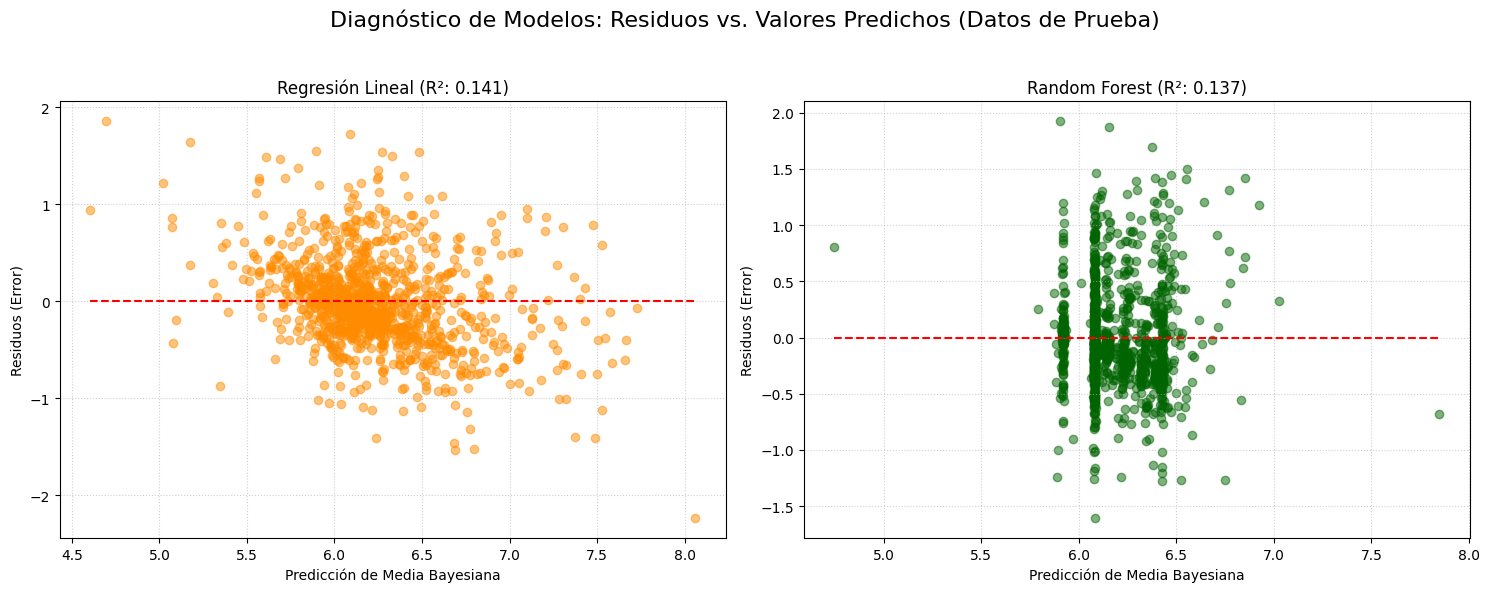

In [41]:
# Gráfico de Residuos vs. Predicciones

# Cálculo de residuos
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Diagnóstico de Modelos: Residuos vs. Valores Predichos (Datos de Prueba)', fontsize=16)

# Regresión Lineal
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='darkorange')
axes[0].hlines(0, y_pred_lr.min(), y_pred_lr.max(), color='red', linestyle='--')
axes[0].set_title(f'Regresión Lineal (R²: {r2_lr:.3f})')
axes[0].set_xlabel('Predicción de Media Bayesiana')
axes[0].set_ylabel('Residuos (Error)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Random Forest Regressor
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='darkgreen')
axes[1].hlines(0, y_pred_rf.min(), y_pred_rf.max(), color='red', linestyle='--')
axes[1].set_title(f'Random Forest (R²: {r2_rf:.3f})')
axes[1].set_xlabel('Predicción de Media Bayesiana')
axes[1].set_ylabel('Residuos (Error)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

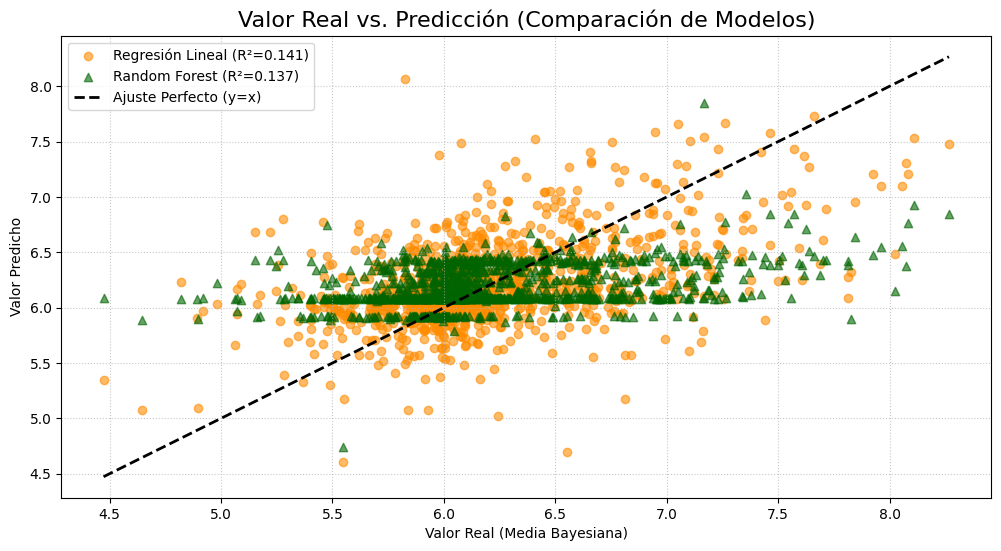

In [42]:
# Gráfico de Valor Real vs. Predicción

plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label=f'Regresión Lineal (R²={r2_lr:.3f})', color='darkorange')
plt.scatter(y_test, y_pred_rf, alpha=0.6, label=f'Random Forest (R²={r2_rf:.3f})', color='darkgreen', marker='^')

# Línea de ajuste perfecto (y=x)
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ajuste Perfecto (y=x)')

plt.title('Valor Real vs. Predicción (Comparación de Modelos)', fontsize=16)
plt.xlabel('Valor Real (Media Bayesiana)')
plt.ylabel('Valor Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [40]:
# --- 8. Conclusiones ---

print("\n--- Conclusiones ---")
print(f"Random Forest (R²: {r2_rf:.4f}) superó a la Regresión Lineal (R²: {r2_lr:.4f}).")


--- Conclusiones ---
Random Forest (R²: 0.1374) superó a la Regresión Lineal (R²: 0.1410).
